## Import Libraies & Cleaning data

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout

In [42]:
df = pd.read_csv("../data/TSLA.csv")        # read data
df.head

<bound method NDFrame.head of             Date        Open        High         Low       Close   Adj Close  \
0     2010-06-29   19.000000   25.000000   17.540001   23.889999   23.889999   
1     2010-06-30   25.790001   30.420000   23.299999   23.830000   23.830000   
2     2010-07-01   25.000000   25.920000   20.270000   21.959999   21.959999   
3     2010-07-02   23.000000   23.100000   18.709999   19.200001   19.200001   
4     2010-07-06   20.000000   20.000000   15.830000   16.110001   16.110001   
...          ...         ...         ...         ...         ...         ...   
2411  2020-01-28  568.489990  576.809998  558.080017  566.900024  566.900024   
2412  2020-01-29  575.690002  589.799988  567.429993  580.989990  580.989990   
2413  2020-01-30  632.419983  650.880005  618.000000  640.809998  640.809998   
2414  2020-01-31  640.000000  653.000000  632.520020  650.570007  650.570007   
2415  2020-02-03  673.690002  786.140015  673.520020  780.000000  780.000000   

        V

In [43]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


### Understand and Clean Data

In [44]:
df.shape     # check no. of rows & columns

(2416, 7)

In [45]:
df.head()    # check top 5 data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [46]:
df.tail()    # check top 5 down

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


In [47]:
df.info()     # check data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


### Check Missing Values

In [48]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

### Check Duplicate Values

In [49]:
df.duplicated().sum()

np.int64(0)

##### duplicate values are not present but if duplicates values are present then we will use ↓

In [50]:
df.drop_duplicates(inplace=True)

### Convert Date Column

In [51]:
df["Date"].dtype

dtype('O')

In [52]:
df["Date"] = pd.to_datetime(df["Date"])

In [53]:
df.info() # checking date type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.3 KB


### Set Date as Index

In [54]:
df.set_index("Date", inplace = True)

In [55]:
df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Statistical


In [56]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [57]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(2416, 6)
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
0


## Exploratory Data Analysis (EDA)

chart 1. Plot Tesla Closing Price Trend

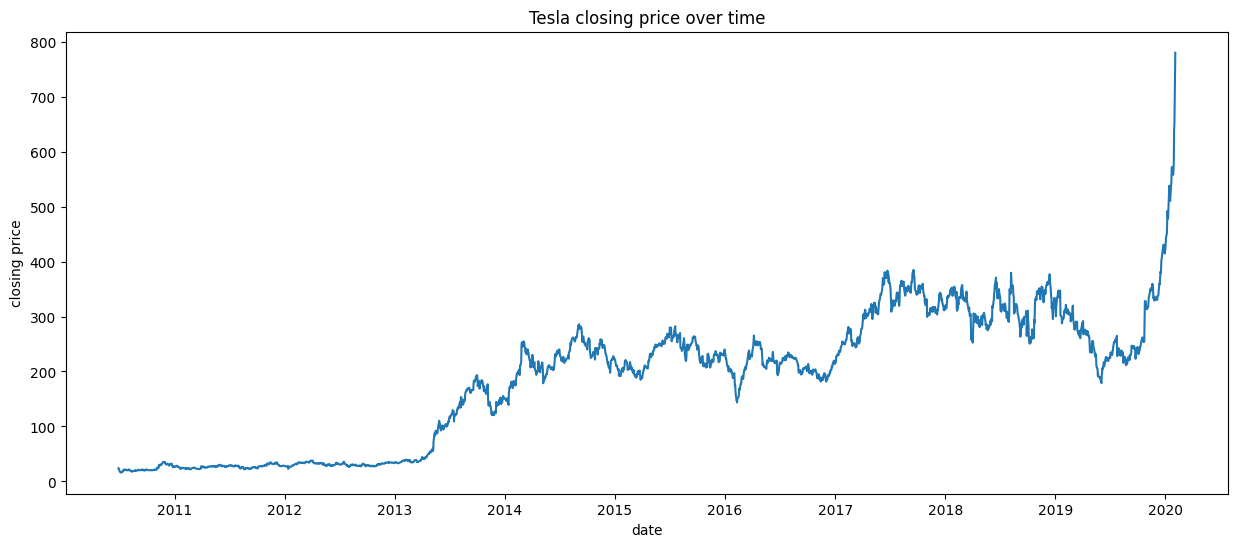

In [58]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'])
plt.title("Tesla closing price over time")
plt.xlabel("date")
plt.ylabel("closing price")

plt.show()

Observation:

Tesla stock shows a strong long-term upward trend from 2010 to 2020.
Price remained relatively stable between 2010 and 2013.
Significant growth started after 2013.
A sharp rise is visible near 2020, indicating strong bullish momentum.
The stock exhibits periods of high volatility and rapid price appreciation.

Report Statement:

Tesla's closing price demonstrates substantial growth over the observed period, reflecting increasing investor confidence and company expansion. The stock also experiences periods of volatility, making it suitable for time-series forecasting analysis.

### Plot Trading Volume

<function matplotlib.pyplot.show(close=None, block=None)>

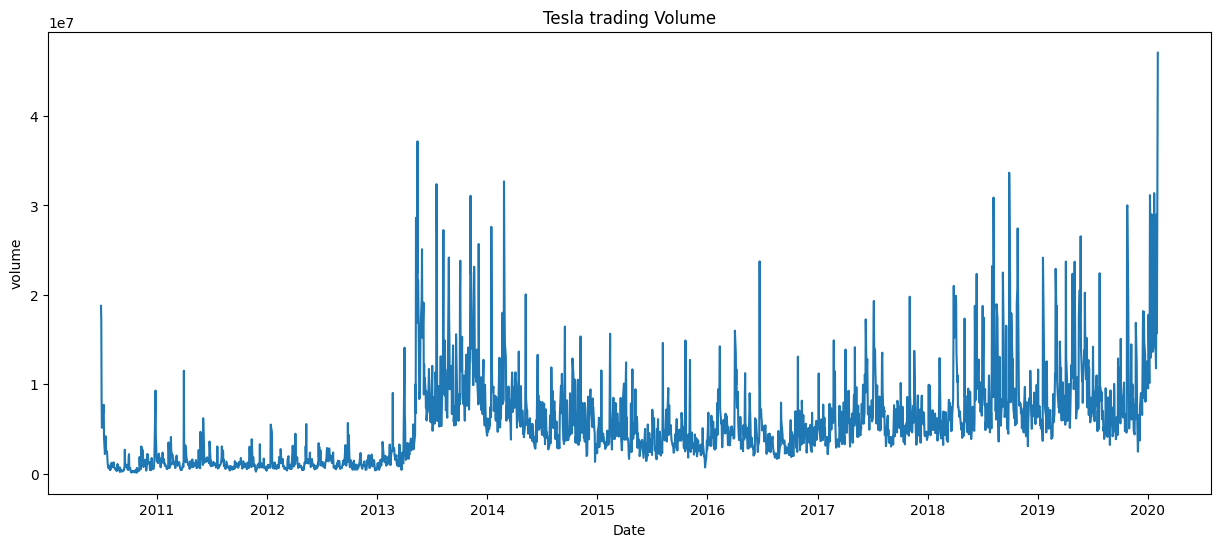

In [59]:
plt.figure(figsize=(15,6))

plt.plot(df['Volume'])

plt.title("Tesla trading Volume")
plt.xlabel("Date")
plt.ylabel("volume")

plt.show

Observation:

Trading volume fluctuates significantly across the years.
Several volume spikes indicate major market events or investor reactions.
Higher volume is observed during major price movements.
Trading activity increases considerably toward 2020.

Report Statement:

Trading volume exhibits multiple spikes, indicating periods of heightened investor participation. Increased volume often coincides with significant price movements, suggesting strong market reactions.

### 7-Day Moving Average

In [60]:
df['MA_7'] = df['Close'].rolling(window=7).mean()

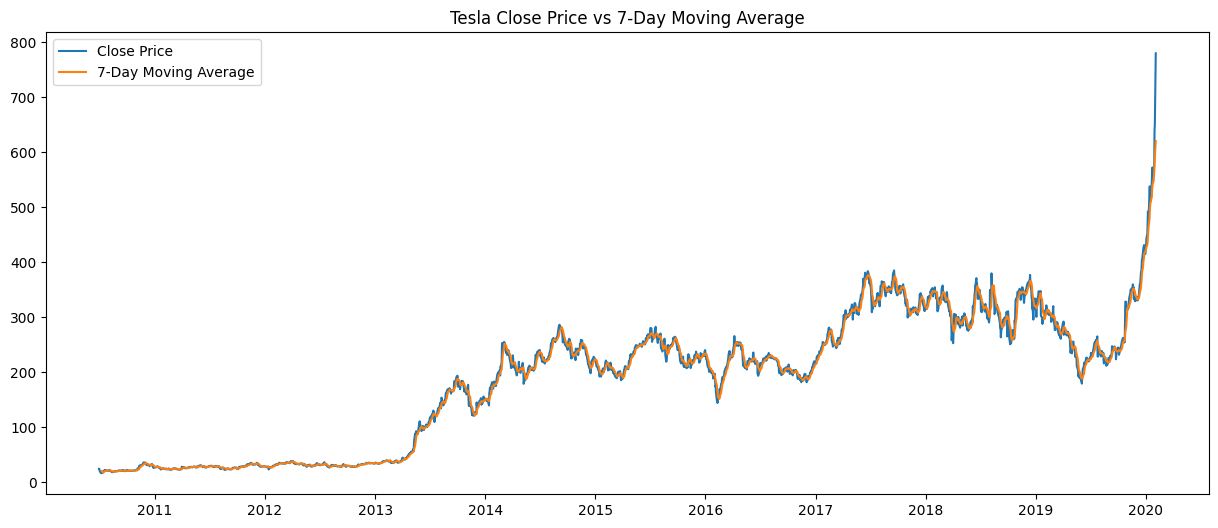

In [61]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_7'], label='7-Day Moving Average')

plt.title("Tesla Close Price vs 7-Day Moving Average")

plt.legend()

plt.show()

Observation:

The 7-day moving average closely follows the actual closing price.
Short-term fluctuations are smoothed effectively.
It captures short-term market trends while reducing noise.

Report Statement:

The 7-day moving average successfully smooths short-term fluctuations and highlights near-term trends in Tesla's stock price movement.

### 30-Day Moving Average

In [62]:
df['MA_30'] = df['Close'].rolling(window=30).mean()

<function matplotlib.pyplot.show(close=None, block=None)>

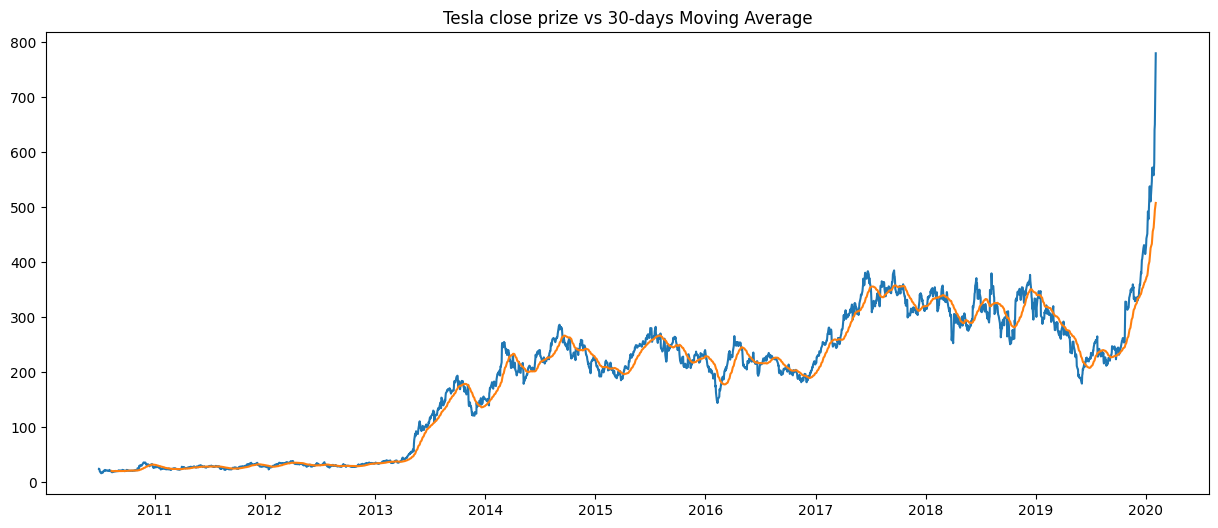

In [63]:
plt.figure(figsize= (15,6))

plt.plot(df['Close'], label= 'close price')
plt.plot(df['MA_30'], label= '30-day moving average')

plt.title("Tesla close prize vs 30-days Moving Average")

plt.legend

plt.show

Observation:

Most daily returns are concentrated around zero.
Several positive and negative spikes indicate high volatility periods.
Extreme return values suggest sudden market reactions.

Report Statement:

Daily returns fluctuate around zero, with occasional large spikes reflecting periods of heightened market volatility and investor sentiment changes.

### Daily Returns

In [64]:
df['Daily_Return'] = df['Close'].pct_change()

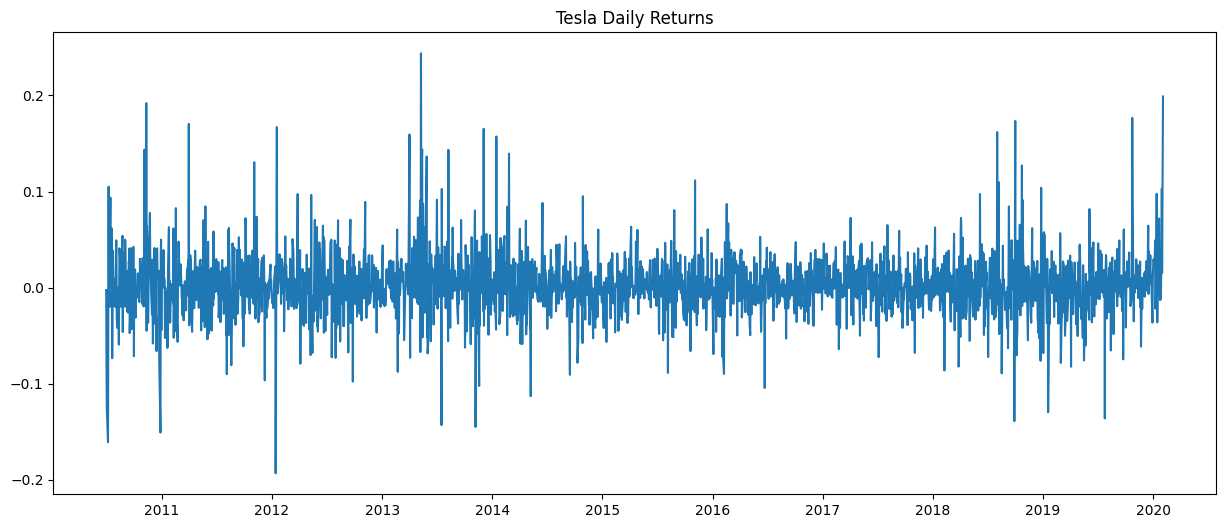

In [65]:
plt.figure(figsize=(15,6))

plt.plot(df['Daily_Return'])

plt.title("Tesla Daily Returns")

plt.show()

### Correlation Heatmap

In [66]:
import seaborn as sns

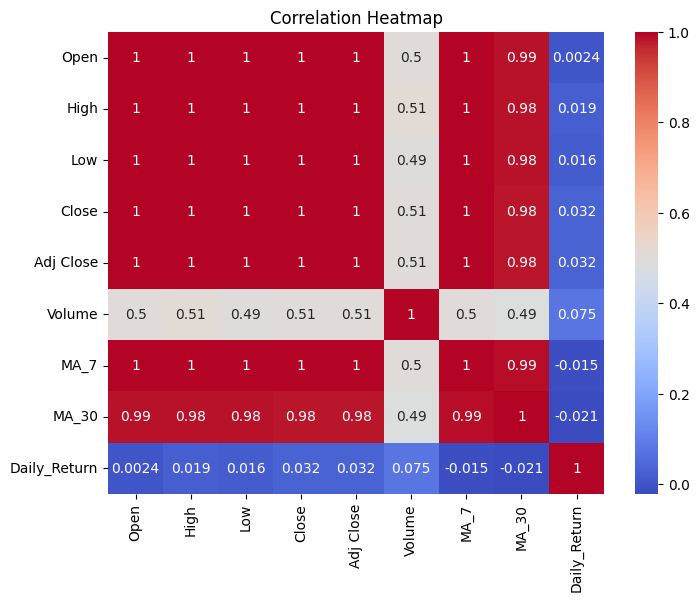

In [67]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Observation:

Open, High, Low, Close, and Adj Close are almost perfectly correlated (~1.0).
Volume has moderate correlation (~0.5).
Daily Return has very weak correlation with price-related features.

Report Statement:

Strong positive correlations exist among price-based variables, indicating they move together over time. Daily returns show weak correlation with other variables, reflecting independent day-to-day market fluctuations.

### Distribution of Closing Price

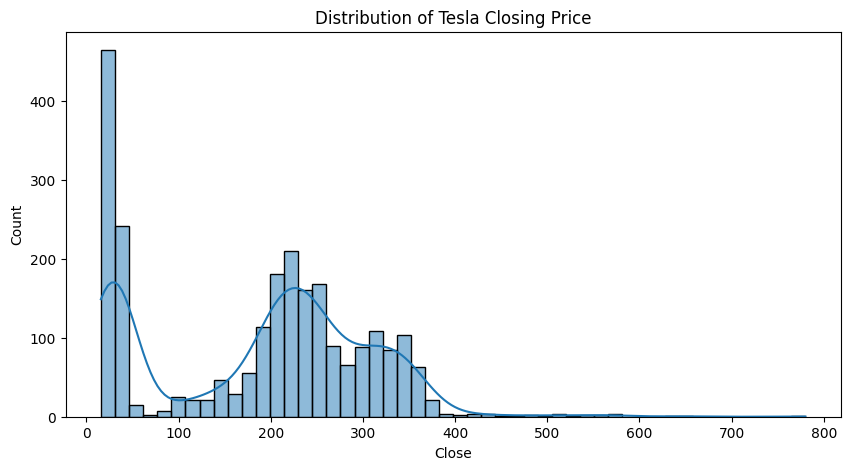

In [68]:
plt.figure(figsize=(10,5))

sns.histplot(df['Close'], bins=50, kde=True)

plt.title("Distribution of Tesla Closing Price")

plt.show()

Observation:

Distribution is right-skewed.
Most observations lie between 20 and 350.
Few extremely high prices create a long right tail.
Data is not normally distributed.

Report Statement:

Tesla's closing prices exhibit a positively skewed distribution with a long right tail, indicating the presence of a few exceptionally high price observations.

### Feature Engineering

This is where we prepare data for RNN and LSTM.